# Weerdata AWS_1DAY

- We halen de data op via de URL (netwerk) en geven de nodige parameters mee. 
  - de URL is te zien bij het netwerk
- Dit script dient elke dag te laden zodat data automatisch wordt geladen in de database (elke dag om 23:59:59)

In [10]:
import requests
from datetime import datetime, timedelta
import pandas as pd
import io
from pathlib import Path
import sys

ROOT = Path().resolve().parents[1] 
sys.path.append(str(ROOT))

from DWH.connection.connect import loadIN

In [11]:
BASE_URL = "https://opendata.meteo.be/service/ows"


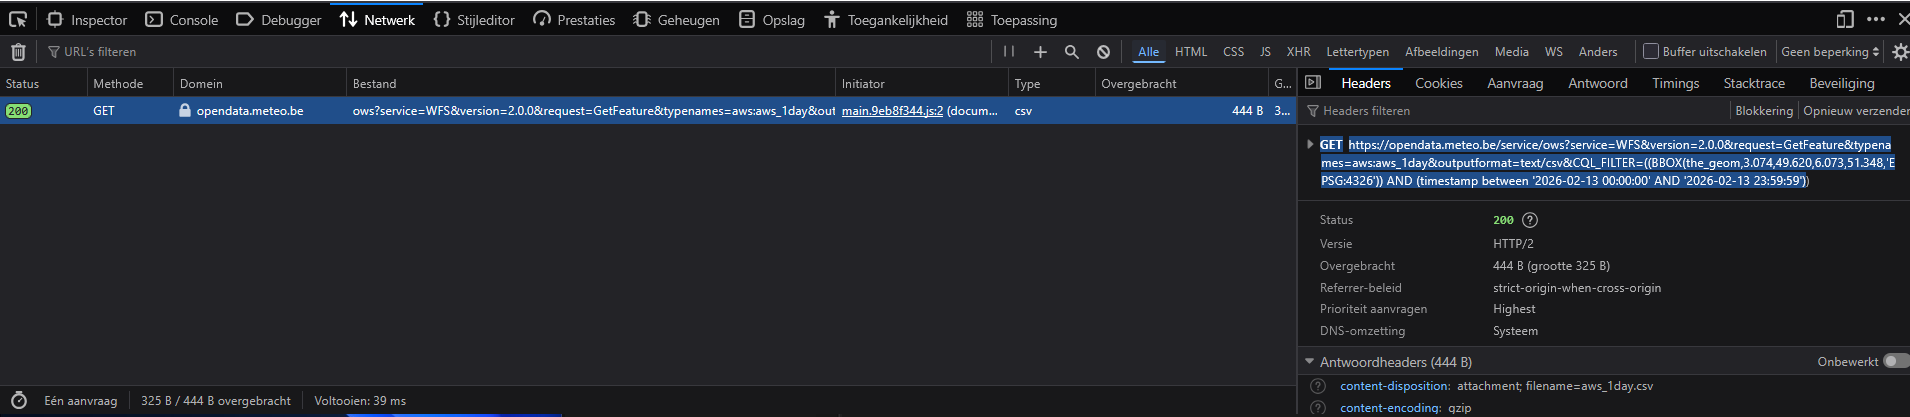

In [12]:
def download_weather_for_date(date):
    start = date.strftime("%Y-%m-%d 00:00:00")
    end = date.strftime("%Y-%m-%d 23:59:59")
    date_str = date.date()
    
    params = {
        "service": "WFS",
        "version": "2.0.0",
        "request": "GetFeature",
        "typenames": "aws:aws_1day",
        "outputformat": "text/csv",
        "CQL_FILTER": f"timestamp between '{start}' AND '{end}'"
    }

    print(f"Ophalen data voor {date_str}")

    try:
        response = requests.get(BASE_URL, params=params)
        response.raise_for_status()
        
        if not response.text.strip():
            print(f"Geen data gevonden voor {date_str}")
            return None

        df = pd.read_csv(io.StringIO(response.text))
        
        # 1. DateKey en TimeKey aanmaken VOORDAT we de timestamp droppen
        if 'timestamp' in df.columns:
            # Zet om naar datetime object
            temp_ts = pd.to_datetime(df['timestamp'])
            df['DateKey'] = temp_ts.dt.strftime('%Y%m%d').astype(int)
        
        # 2. Opschonen van originele API kolommen
        cols_to_drop = ['FID', 'qc_flags', 'the_geom', 'timestamp']
        df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
        
        # 3. Kolommen hernoemen naar PascalCase conform SQL tabel
        df.rename(columns={
            "code": "WeatherStationKey",
            "precip_quantity": "PrecipQuantity",
            "temp_avg": "TempAvg",
            "temp_max": "TempMax",
            "temp_min": "TempMin",
            "temp_grass_pt100_avg": "TempGrassPt100Avg",
            "temp_soil_avg": "TempSoilAvg",
            "temp_soil_avg_5cm": "TempSoilAvg5cm",
            "temp_soil_avg_10cm": "TempSoilAvg10cm",
            "temp_soil_avg_20cm": "TempSoilAvg20cm",
            "temp_soil_avg_50cm": "TempSoilAvg50cm",
            "wind_speed_10m": "WindSpeed10m",
            "wind_speed_avg_30m": "WindSpeedAvg30m",
            "wind_gusts_speed": "WindGustsSpeed",
            "humidity_rel_shelter_avg": "HumidityRelShelterAvg",
            "pressure": "Pressure",
            "sun_duration": "SunDuration",
            "short_wave_from_sky_avg": "ShortWaveFromSkyAvg",
            "sun_int_avg": "SunIntAvg"
        }, inplace=True)

        # Pad bepaling
        try:
            base_path = Path(__file__).resolve().parent
        except NameError:
            base_path = Path.cwd()

        project_root = base_path.parent.parent
        output_dir = project_root / "data" / "weatherData" / "aws_1day"
        output_dir.mkdir(parents=True, exist_ok=True)
        
        file_path = output_dir / f"aws_1day_{date_str}.csv"
        
        # Opslaan als CSV
        df.to_csv(file_path, index=False)
        print(f"Download en hernoeming voltooid: {file_path}")

    except Exception as e:
        print(f"Er ging iets mis bij {date_str}: {e}")
        return None
    
    return df

In [13]:
loadIN(table="FactMeteo", df=download_weather_for_date(datetime.now() - timedelta(days=1))) #yesterdays data

Ophalen data voor 2026-02-16
Download en hernoeming voltooid: c:\Users\Luizv\Documents\HoGent\jaar2\dep\data\weatherData\aws_1day\aws_1day_2026-02-16.csv


'data has been loaded into table FactMeteo in database DEPI within the localhost server'